In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:

from google.colab import files

# Step 2: Upload the file
uploaded = files.upload()

# Step 3: Load dataset
df = pd.read_csv("microsoft_loan.csv")

# Step 4: Check first few rows
df.head()


,memberId,residentialState,yearsEmployment,homeOwnership,annualIncome,incomeVerified,dtiRatio,lengthCreditHistory,numTotalCreditLines,numOpenCreditLines,numOpenCreditLines1Year,revolvingBalance,revolvingUtilizationRate,numDerogatoryRec,numDelinquency2Years,numChargeoff1year,numInquiries6Mon
0,2305095,NM,10+ years,rent,56471,1,16.80,6,11,9.0,6,14301,49.02,0,19,10,0
1,2610493,WA,2-5 years,rent,55038,0,19.99,22,8,7.0,4,18262,72.40,1,0,0,0
2,2491679,MS,< 1 year,rent,56610,1,14.33,5,8,5.0,5,10799,66.27,0,1,1,0
3,2092798,TX,6-9 years,own,54887,1,14.80,12,14,7.0,3,15272,61.05,1,0,0,3
4,2633077,MA,2-5 years,rent,53522,1,10.14,4,21,19.0,10,19316,56.39,2,14,7,1


In [4]:
print("Data types & missing values")
df.info()


Data types & missing values
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 17 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   memberId                  100000 non-null  int64  
 1   residentialState          100000 non-null  object 
 2   yearsEmployment           100000 non-null  object 
 3   homeOwnership             100000 non-null  object 
 4   annualIncome              100000 non-null  int64  
 5   incomeVerified            100000 non-null  int64  
 6   dtiRatio                  100000 non-null  float64
 7   lengthCreditHistory       100000 non-null  int64  
 8   numTotalCreditLines       100000 non-null  int64  
 9   numOpenCreditLines        99033 non-null   float64
 10  numOpenCreditLines1Year   100000 non-null  int64  
 11  revolvingBalance          100000 non-null  int64  
 12  revolvingUtilizationRate  100000 non-null  float64
 13  numDerogatoryRec 

In [6]:
# Descriptive statistics for the 'annualIncome' column
income_stats = {
    "Mean": df["annualIncome"].mean(),
    "Median": df["annualIncome"].median(),
    "Standard Deviation": df["annualIncome"].std(),
    "Minimum": df["annualIncome"].min(),
    "Maximum": df["annualIncome"].max(),
    "Range": df["annualIncome"].max() - df["annualIncome"].min(),
    "Variance": df["annualIncome"].var(),
    "Skewness": df["annualIncome"].skew()
}

print("DESCRIPTIVE STATS OF Income COLUMN")
for stat, value in income_stats.items():
    print(f"{stat}: {value}")


DESCRIPTIVE STATS OF Income COLUMN
Mean: 54718.01314
Median: 54781.0
Standard Deviation: 3178.6272861223356
Minimum: 38328
Maximum: 69553
Range: 31225
Variance: 10103671.424081445
Skewness: -0.14014619401469872


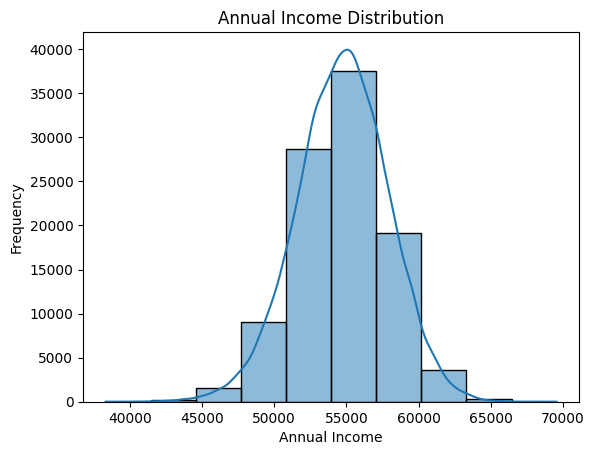

In [8]:
sns.histplot(df['annualIncome'], bins=10, kde=True, fill=True)
plt.xlabel('Annual Income')
plt.ylabel('Frequency')
plt.title('Annual Income Distribution')
plt.show()


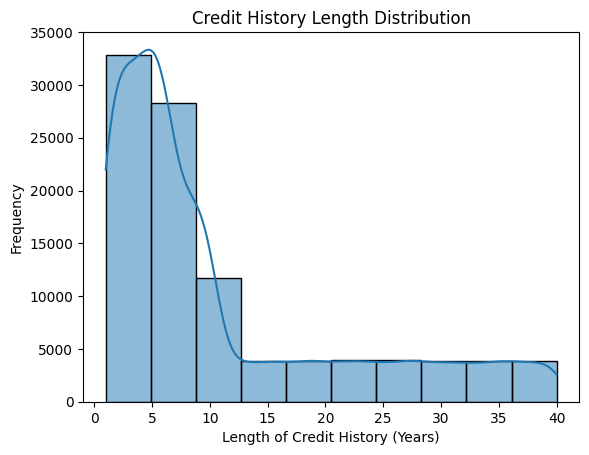

In [9]:
sns.histplot(df['lengthCreditHistory'], bins=10, kde=True, fill=True)
plt.xlabel('Length of Credit History (Years)')
plt.ylabel('Frequency')
plt.title('Credit History Length Distribution')
plt.show()


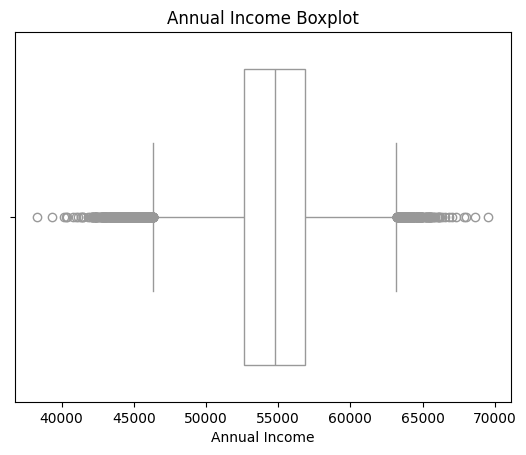

In [10]:
sns.boxplot(x=df['annualIncome'], color='white')
plt.xlabel('Annual Income')
plt.title('Annual Income Boxplot')
plt.show()


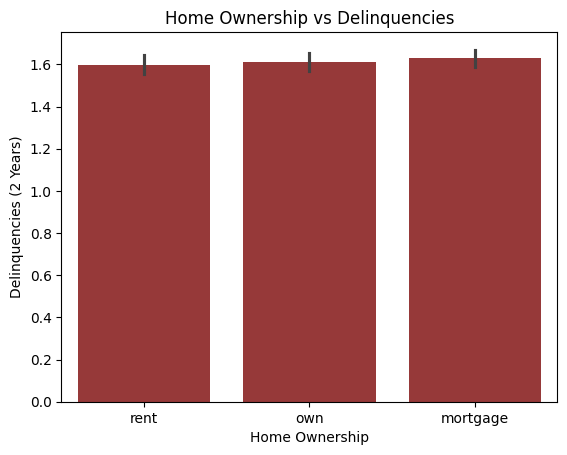

In [12]:
sns.barplot(data=df, x='homeOwnership', y='numDelinquency2Years', color='brown')
plt.xlabel('Home Ownership')
plt.ylabel('Delinquencies (2 Years)')
plt.title('Home Ownership vs Delinquencies')
plt.show()

In [13]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
numeric_cols

Index(['memberId', 'annualIncome', 'incomeVerified', 'dtiRatio',
       'lengthCreditHistory', 'numTotalCreditLines', 'numOpenCreditLines',
       'numOpenCreditLines1Year', 'revolvingBalance',
       'revolvingUtilizationRate', 'numDerogatoryRec', 'numDelinquency2Years',
       'numChargeoff1year', 'numInquiries6Mon'],
      dtype='object')

In [14]:
print("OUTLIER COUNT IN EACH NUMERIC COLUMN")

outliers = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    outliers.append((col, outlier_count))

# Convert to DataFrame for better readability
outliers_df = pd.DataFrame(outliers, columns=["Column", "Outlier_Count"])
outliers_df = outliers_df.sort_values(by="Outlier_Count", ascending=False).reset_index(drop=True)

print(outliers_df)


OUTLIER COUNT IN EACH NUMERIC COLUMN
                      Column  Outlier_Count
0           numDerogatoryRec          18302
1       numDelinquency2Years          15073
2          numChargeoff1year          13499
3           numInquiries6Mon          11234
4        lengthCreditHistory           8665
5               annualIncome           1014
6    numOpenCreditLines1Year            916
7         numOpenCreditLines            852
8                   dtiRatio            686
9           revolvingBalance            638
10  revolvingUtilizationRate            315
11       numTotalCreditLines            196
12            incomeVerified              0
13                  memberId              0


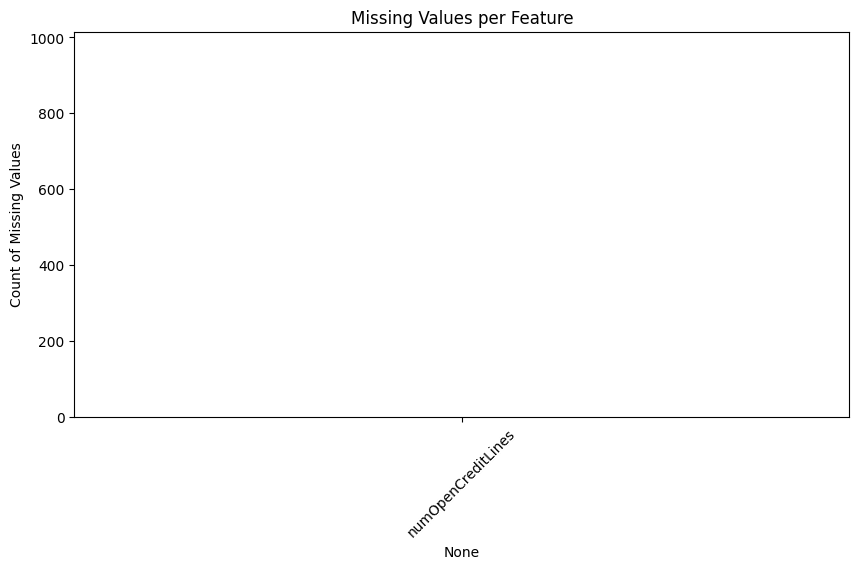

In [21]:

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(10,5))
# Use a single color instead of palette
sns.barplot(x=missing.index, y=missing.values, color="white")
plt.title("Missing Values per Feature")
plt.ylabel("Count of Missing Values")
plt.xticks(rotation=45)
plt.show()


In [22]:
print(df.isnull().sum())

memberId                      0
residentialState              0
yearsEmployment               0
homeOwnership                 0
annualIncome                  0
incomeVerified                0
dtiRatio                      0
lengthCreditHistory           0
numTotalCreditLines           0
numOpenCreditLines          967
numOpenCreditLines1Year       0
revolvingBalance              0
revolvingUtilizationRate      0
numDerogatoryRec              0
numDelinquency2Years          0
numChargeoff1year             0
numInquiries6Mon              0
dtype: int64


In [24]:
mean_value = df['numOpenCreditLines'].mean()
# Fill missing values with the mean
df['numOpenCreditLines'].fillna(mean_value, inplace=True)

/tmp/ipython-input-3721371048.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['numOpenCreditLines'].fillna(mean_value, inplace=True)


In [25]:
print(df.isnull().sum())

memberId                    0
residentialState            0
yearsEmployment             0
homeOwnership               0
annualIncome                0
incomeVerified              0
dtiRatio                    0
lengthCreditHistory         0
numTotalCreditLines         0
numOpenCreditLines          0
numOpenCreditLines1Year     0
revolvingBalance            0
revolvingUtilizationRate    0
numDerogatoryRec            0
numDelinquency2Years        0
numChargeoff1year           0
numInquiries6Mon            0
dtype: int64


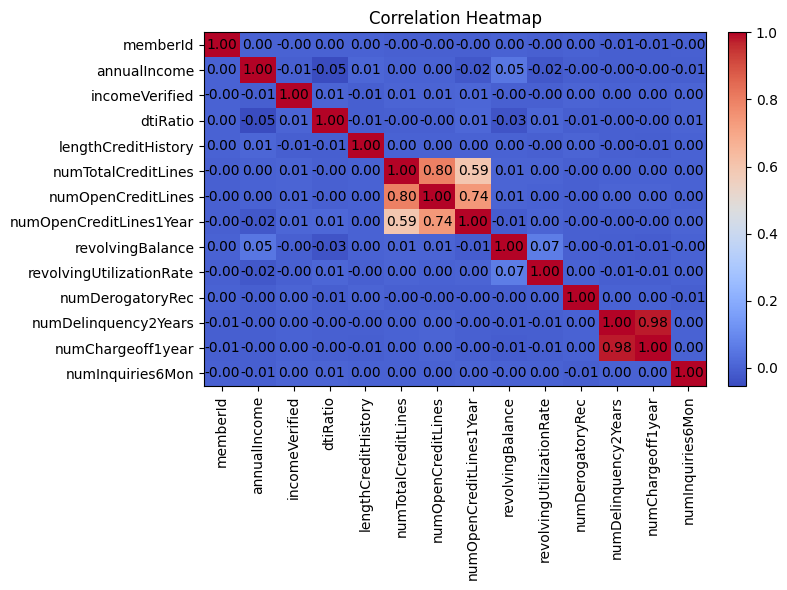

In [27]:
if len(numeric_cols) >= 2:
    corr = df[numeric_cols].corr(numeric_only=True)

    plt.figure(figsize=(8,6))
    im = plt.imshow(corr, aspect='auto', cmap="coolwarm")

    # Axis labels
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.index)), corr.index)

    # Add correlation values on the heatmap
    for i in range(len(corr.columns)):
        for j in range(len(corr.index)):
            plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                     ha='center', va='center', color='black')

    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()


In [28]:
outlier_summary = []

for col in numeric_cols:
    # Drop missing values for this column
    s = df[col].dropna()
    if s.empty:
        continue

    # Calculate Q1, Q3, and IQR
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1

    # Define outlier boundaries
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR

    # Count outliers
    count = ((s < lower) | (s > upper)).sum()

    # Append summary: feature, outlier count, outlier ratio
    outlier_summary.append((col, int(count), round(count/len(df), 3)))

# Create DataFrame with outlier information
outlier_df = pd.DataFrame(outlier_summary, columns=["feature", "outlier_count", "outlier_ratio"])

# Display top 20 features with highest outlier ratio
print("\n📌 Outlier Analysis")
display(outlier_df.sort_values("outlier_ratio", ascending=False).head(20))


📌 Outlier Analysis


,feature,outlier_count,outlier_ratio
10,numDerogatoryRec,18302,0.183
11,numDelinquency2Years,15073,0.151
12,numChargeoff1year,13499,0.135
13,numInquiries6Mon,11234,0.112
4,lengthCreditHistory,8665,0.087
1,annualIncome,1014,0.010
7,numOpenCreditLines1Year,916,0.009
6,numOpenCreditLines,852,0.009
3,dtiRatio,686,0.007
8,revolvingBalance,638,0.006


In [29]:
# Cap outliers for all numeric columns
for col in numeric_cols:
    s = df[col].dropna()
    if s.empty:
        continue

    # Calculate IQR
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR

    # Cap the values
    df[col] = df[col].clip(lower=lower, upper=upper)

# Verify
outlier_check = []
for col in numeric_cols:
    s = df[col].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    count = ((s < lower) | (s > upper)).sum()
    outlier_check.append((col, count))

outlier_check_df = pd.DataFrame(outlier_check, columns=["feature", "outlier_count"])
print("\n✅ Outlier counts after capping:")
display(outlier_check_df.sort_values("outlier_count", ascending=False))



✅ Outlier counts after capping:


,feature,outlier_count
0,memberId,0
1,annualIncome,0
2,incomeVerified,0
3,dtiRatio,0
4,lengthCreditHistory,0
5,numTotalCreditLines,0
6,numOpenCreditLines,0
7,numOpenCreditLines1Year,0
8,revolvingBalance,0
9,revolvingUtilizationRate,0


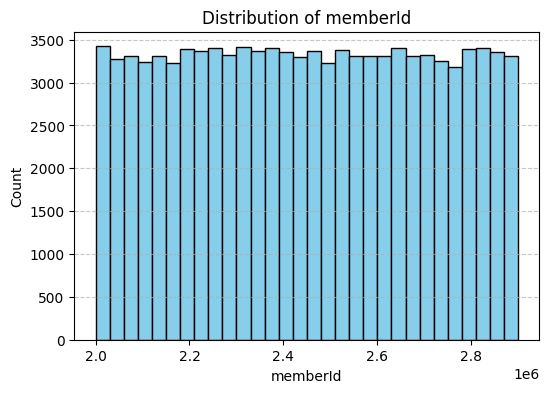

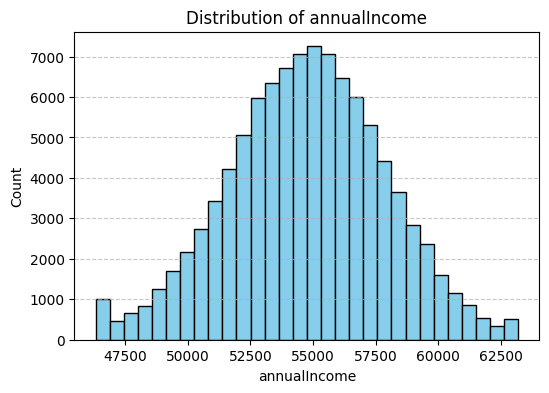

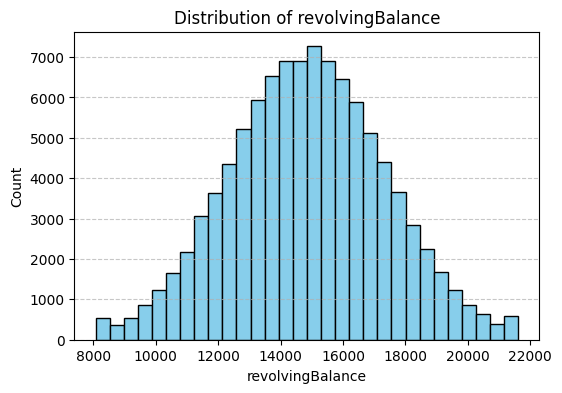

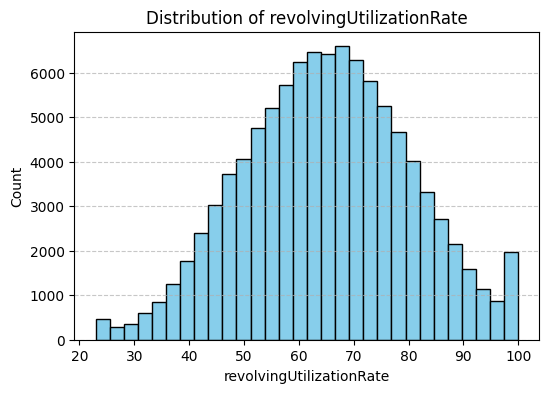

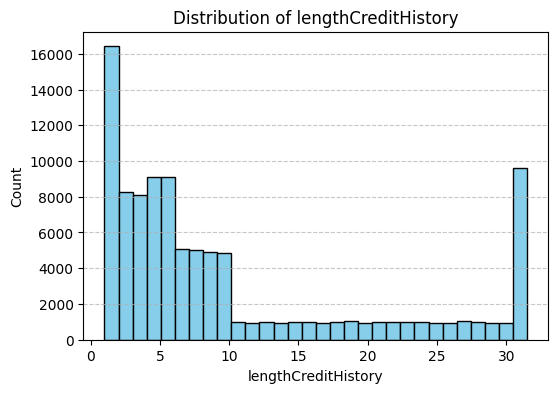

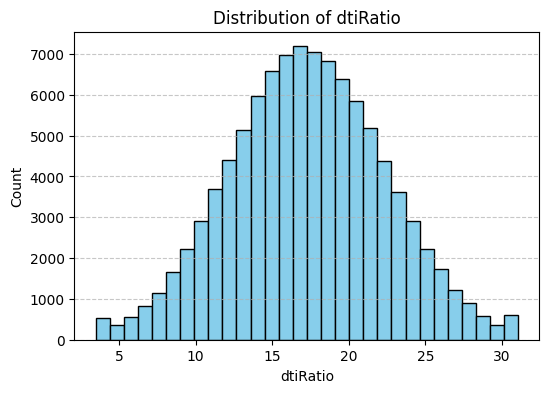

In [30]:
# Calculate variances of numeric columns and sort descending
variances = df[numeric_cols].var(numeric_only=True).sort_values(ascending=False)

# Select top 6 features (or fewer if less than 6)
key_features = variances.index[:min(6, len(variances))].tolist()

# Plot histograms for each key feature
for col in key_features:
    plt.figure(figsize=(6,4))
    df[col].dropna().plot(kind="hist", bins=30, edgecolor="black", color="skyblue")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

In [32]:
# Identify numeric and categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in df.columns if c not in numeric_cols]

# Summary statistics for numeric columns
summary_numeric = df[numeric_cols].describe().T  # Transpose for easier reading

# Missing value ratios for all columns
missing = df.isna().mean().sort_values(ascending=False).rename("missing_ratio")

# Display results
print("\n📊 Summary Statistics (Numeric Columns)")
display(summary_numeric)

print("\n📌 Missing Value Ratios (Top 20 Columns)")
display(missing.head(20))


📊 Summary Statistics (Numeric Columns)


,count,mean,std,min,25%,50%,75%,max
memberId,100000.0,2.449892e+06,259611.141422,2000006.000,2226132.75,2448687.00,2674203.50,2899987.000
annualIncome,100000.0,5.472442e+04,3143.146457,46321.000,52648.00,54781.00,56866.00,63193.000
incomeVerified,100000.0,6.860700e-01,0.464091,0.000,0.00,1.00,1.00,1.000
dtiRatio,100000.0,1.728009e+01,5.070548,3.470,13.82,17.24,20.72,31.070
lengthCreditHistory,100000.0,1.053079e+01,9.762707,1.000,4.00,6.00,15.00,31.500
numTotalCreditLines,100000.0,1.501570e+01,3.997866,3.000,12.00,15.00,18.00,27.000
numOpenCreditLines,100000.0,1.126284e+01,3.714310,1.500,9.00,11.00,14.00,21.500
numOpenCreditLines1Year,100000.0,7.589570e+00,3.355834,1.000,5.00,7.00,10.00,17.500
revolvingBalance,100000.0,1.484864e+04,2493.102466,8069.125,13150.00,14852.00,16537.25,21618.125
revolvingUtilizationRate,100000.0,6.510584e+01,15.240979,22.945,54.52,65.18,75.57,100.000



📌 Missing Value Ratios (Top 20 Columns)


,missing_ratio
memberId,0.0
residentialState,0.0
yearsEmployment,0.0
homeOwnership,0.0
annualIncome,0.0
incomeVerified,0.0
dtiRatio,0.0
lengthCreditHistory,0.0
numTotalCreditLines,0.0
numOpenCreditLines,0.0
